# IMPORTACIÓN DE LIBRERÍAS

In [84]:
#IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# import preproccesing libraries
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# import  ML models 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# import visualization's libraries
import graphviz
import pydot
from sklearn.tree import plot_tree

# IMPORTACIÓN DE BASE DE DATOS Y PREPROCESAMIENTO

## Importación de base de datos

In [68]:
#IMPORTACIÓN DE BASE DE DATOS
tabla=pd.read_excel(r"I:\Mi unidad\1 - TECNICATURA EN CIENCIAS DE DATOS E INTELIGENCIA ARTIFICIAL\3 - TERCER SEMESTRE\1 - APRENDIZAJE AUTOMÁTICO I\3 - Exámenes\2 - Parcial 2\2 - Tabla_GDP_1parcial.xlsx",decimal=",")
t2=pd.DataFrame(tabla)
t3=pd.DataFrame(tabla)
t2

,province,gdp,illiteracy,poverty,deficient_infra,school_dropout,no_healthcare,birth_mortal,pop,movie_theatres_per_cap,doctors_per_cap
0,Buenos Aires,2.926899e+08,1.383240,8.167798,5.511856,0.766168,48.7947,4.4,15625084,0.000006,0.004836
1,Catamarca,6.150949e+06,2.344140,9.234095,10.464484,0.951963,45.0456,1.5,367828,0.000005,0.004502
2,Córdoba,6.936374e+07,2.714140,5.382380,10.436086,1.035056,45.7640,4.8,3308876,0.000011,0.010175
3,Corrientes,7.968013e+06,NaN,12.747191,17.438858,3.864265,62.1103,5.9,992595,0.000004,0.004495
4,Chaco,9.832643e+06,7.517580,15.862619,31.479527,2.577462,65.5104,7.5,1055259,0.000003,0.003605
5,Chubut,1.774785e+07,1.548060,8.051752,8.044618,0.586309,39.5473,3.0,509108,0.000016,0.004498
6,Entre Ríos,2.074341e+07,3.185580,7.288751,18.794568,NaN,NaN,3.1,1235994,0.000006,0.004679
7,Formosa,3.807057e+06,4.610640,17.035583,28.004985,2.268974,65.8126,16.2,530162,0.000004,0.003440
8,Jujuy,NaN,2.151390,13.367965,12.483179,0.721295,54.1615,3.7,673307,0.000003,0.003958
9,La Pampa,6.990262e+06,1.539300,3.398774,16.505714,0.204093,45.4764,7.2,318951,0.000019,0.005415


## Completamos valores nulos

In [69]:
#COMPLETAR VALORES FALTANTES CON MEDIA
t2 = t2.apply(lambda col: col.fillna(col.mean()) if col.dtype in ['float64', 'int64'] else col)
t2

,province,gdp,illiteracy,poverty,deficient_infra,school_dropout,no_healthcare,birth_mortal,pop,movie_theatres_per_cap,doctors_per_cap
0,Buenos Aires,2.926899e+08,1.383240,8.167798,5.511856,0.766168,48.794700,4.4,15625084,0.000006,0.004836
1,Catamarca,6.150949e+06,2.344140,9.234095,10.464484,0.951963,45.045600,1.5,367828,0.000005,0.004502
2,Córdoba,6.936374e+07,2.714140,5.382380,10.436086,1.035056,45.764000,4.8,3308876,0.000011,0.010175
3,Corrientes,7.968013e+06,3.166403,12.747191,17.438858,3.864265,62.110300,5.9,992595,0.000004,0.004495
4,Chaco,9.832643e+06,7.517580,15.862619,31.479527,2.577462,65.510400,7.5,1055259,0.000003,0.003605
5,Chubut,1.774785e+07,1.548060,8.051752,8.044618,0.586309,39.547300,3.0,509108,0.000016,0.004498
6,Entre Ríos,2.074341e+07,3.185580,7.288751,18.794568,1.749807,50.391715,3.1,1235994,0.000006,0.004679
7,Formosa,3.807057e+06,4.610640,17.035583,28.004985,2.268974,65.812600,16.2,530162,0.000004,0.003440
8,Jujuy,3.277525e+07,2.151390,13.367965,12.483179,0.721295,54.161500,3.7,673307,0.000003,0.003958
9,La Pampa,6.990262e+06,1.539300,3.398774,16.505714,0.204093,45.476400,7.2,318951,0.000019,0.005415


In [6]:
#COMPLETAR VALORES FALTANTES CON MEDIA_2
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='mean') #np.nan
t3[['gdp','illiteracy','school_dropout','no_healthcare']]=imp.fit_transform(t3[['gdp','illiteracy','school_dropout','no_healthcare']])
t3

,province,gdp,illiteracy,poverty,deficient_infra,school_dropout,no_healthcare,birth_mortal,pop,movie_theatres_per_cap,doctors_per_cap
0,Buenos Aires,2.926899e+08,1.383240,8.167798,5.511856,0.766168,48.794700,4.4,15625084,0.000006,0.004836
1,Catamarca,6.150949e+06,2.344140,9.234095,10.464484,0.951963,45.045600,1.5,367828,0.000005,0.004502
2,Córdoba,6.936374e+07,2.714140,5.382380,10.436086,1.035056,45.764000,4.8,3308876,0.000011,0.010175
3,Corrientes,7.968013e+06,3.166403,12.747191,17.438858,3.864265,62.110300,5.9,992595,0.000004,0.004495
4,Chaco,9.832643e+06,7.517580,15.862619,31.479527,2.577462,65.510400,7.5,1055259,0.000003,0.003605
5,Chubut,1.774785e+07,1.548060,8.051752,8.044618,0.586309,39.547300,3.0,509108,0.000016,0.004498
6,Entre Ríos,2.074341e+07,3.185580,7.288751,18.794568,1.749807,50.391715,3.1,1235994,0.000006,0.004679
7,Formosa,3.807057e+06,4.610640,17.035583,28.004985,2.268974,65.812600,16.2,530162,0.000004,0.003440
8,Jujuy,3.277525e+07,2.151390,13.367965,12.483179,0.721295,54.161500,3.7,673307,0.000003,0.003958
9,La Pampa,6.990262e+06,1.539300,3.398774,16.505714,0.204093,45.476400,7.2,318951,0.000019,0.005415


## Estandarización de valores

In [70]:
#NORMALIZACIÓN DE DATOS
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
t2[['Z_gdp','Z_poverty','Z_school_dropout']]=scaler.fit_transform(t2[['gdp','poverty','school_dropout']])
t2


,province,gdp,illiteracy,poverty,deficient_infra,school_dropout,no_healthcare,birth_mortal,pop,movie_theatres_per_cap,doctors_per_cap,Z_gdp,Z_poverty,Z_school_dropout
0,Buenos Aires,2.926899e+08,1.383240,8.167798,5.511856,0.766168,48.794700,4.4,15625084,0.000006,0.004836,4.332051e+00,-0.476036,-0.881165
1,Catamarca,6.150949e+06,2.344140,9.234095,10.464484,0.951963,45.045600,1.5,367828,0.000005,0.004502,-4.437528e-01,-0.187273,-0.714726
2,Córdoba,6.936374e+07,2.714140,5.382380,10.436086,1.035056,45.764000,4.8,3308876,0.000011,0.010175,6.098279e-01,-1.230354,-0.640290
3,Corrientes,7.968013e+06,3.166403,12.747191,17.438858,3.864265,62.110300,5.9,992595,0.000004,0.004495,-4.134675e-01,0.764107,1.894176
4,Chaco,9.832643e+06,7.517580,15.862619,31.479527,2.577462,65.510400,7.5,1055259,0.000003,0.003605,-3.823893e-01,1.607794,0.741431
5,Chubut,1.774785e+07,1.548060,8.051752,8.044618,0.586309,39.547300,3.0,509108,0.000016,0.004498,-2.504648e-01,-0.507462,-1.042286
6,Entre Ríos,2.074341e+07,3.185580,7.288751,18.794568,1.749807,50.391715,3.1,1235994,0.000006,0.004679,-2.005373e-01,-0.714090,0.000000
7,Formosa,3.807057e+06,4.610640,17.035583,28.004985,2.268974,65.812600,16.2,530162,0.000004,0.003440,-4.828190e-01,1.925444,0.465081
8,Jujuy,3.277525e+07,2.151390,13.367965,12.483179,0.721295,54.161500,3.7,673307,0.000003,0.003958,6.209019e-17,0.932218,-0.921364
9,La Pampa,6.990262e+06,1.539300,3.398774,16.505714,0.204093,45.476400,7.2,318951,0.000019,0.005415,-4.297638e-01,-1.767533,-1.384683


# REGRESIÓN LINEAL MÚLTIPLE

In [71]:
"""
PROBLEMA: Desarrollar un algoritmo que permita estimar el nivel del PBI en relación a la pobreza y a la deserción escolar en las distintas provincias de la Argentina.
Generar un algoritmo en Python para analizar la relación entre las variables asignadas, a partir de:
1.	Un modelo de regresión lineal que represente la relación entre el predictor y la variable respuesta.
2.	Un modelo de regresión polinómica que describa la relación entre el predictor y la variable respuesta, considerando un polinomio de grado: 2, 3, 4.
3.	Un modelo de clustering, agrupando datos entre el predictor y la variable respuesta.
(*) En todos los modelos, presentar gráficos, métricas y observaciones preliminares.

"""

t2[['gdp','school_dropout','poverty']].dtypes

gdp               float64
school_dropout    float64
poverty           float64
dtype: object

## Dividimos datos para entrenamiento y testeo

In [94]:
# 1) Se quiere predecir el nivel del PBI en relación a la pobreza y la deserción escolar en las distintas provincias de la Argentina.

t2.index=t2['province']

#DIVISIÓN DE DATOS PARA ENTRENAMIENTO Y TESTING
from sklearn.model_selection import train_test_split
x=pd.DataFrame(t2,columns=['Z_poverty','Z_school_dropout'])                   #dataset.data
y=pd.DataFrame(t2,columns=['Z_gdp'])                                          #dataset.target                  

#Particion del dataset con 20% datos para el conjunto de testing, 80% entrenamiento
x_train_model1,x_test_model1,y_train_model1,y_test_model1=train_test_split(x,y,test_size=0.2, random_state=1)

In [73]:
print("x_train shape:",x_train_model1.shape)
print("y_train shape:",y_train_model1.shape)

print("x_test shape:",x_test_model1.shape)
print("y_test shape:",y_test_model1.shape)
y_test_model1

x_train shape: (17, 2)
y_train shape: (17, 1)
x_test shape: (5, 2)
y_test shape: (5, 1)


,Z_gdp
province,
Santa Fe,0.813584
San Juan,-0.408562
Corrientes,-0.413467
Neuquén,-0.170191
Santa Cruz,-0.351870


## Entrenamiento del modelo

In [76]:
#ENTRENAMIENTO REGRESIÓN LINEAL MÚLTIPLE

#Entrenamiento
model1=LinearRegression()
model1.fit(x_train_model1, y_train_model1)

#Predicciones
predictions1=model1.predict(x_test_model1)
predictions1=np.array(predictions1,dtype=float)

predictions1

array([[-0.19294428],
       [-0.3976498 ],
       [-0.66193572],
       [ 0.1018882 ],
       [ 0.44208239]])

## Determinación de coeficientes

In [78]:
#OBTENCIÓN DE COEFICIENTES DE RECTA DE REGRESIÓN LINEAL SIMPLE

#Coeficientes
a1=model1.coef_

#Ordenada al origen
b1=model1.intercept_

print(f'La ecuación lineal que relaciona la el PBI en base a la pobreza en las provincias argentinas es es: y = {round(a1[0][0],3)}x₁ + ({round(a1[0][1],3)})x₂ + ({round(b1[0],3)})')


La ecuación lineal que relaciona la el PBI en base a la pobreza en las provincias argentinas es es: y = -0.112x₁ + (-0.3)x₂ + (-0.008)


## Gráfico de modelo

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


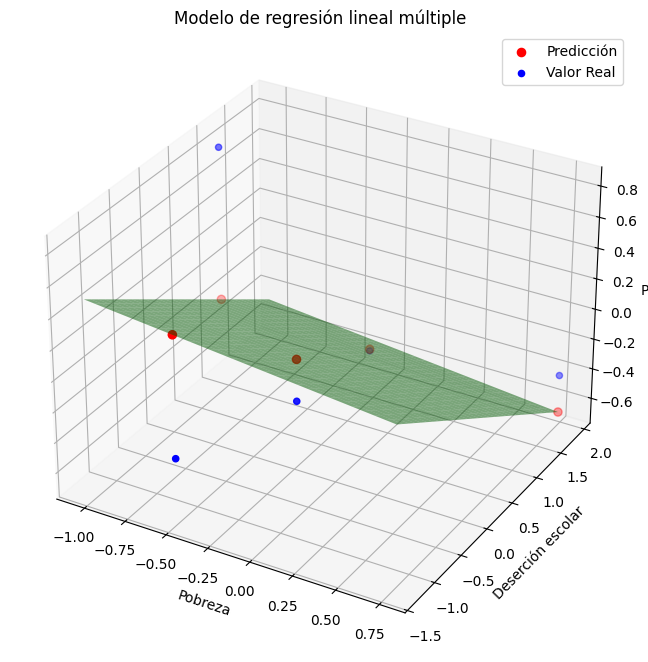

In [79]:
#GRÁFICA DEL PLANO EN TRES DIMENSIONES

#Datos en array bidimensional
nx=x_test_model1[['Z_poverty']]
ny=x_test_model1[['Z_school_dropout']]
nz=predictions1

nx=np.array(nx,dtype=float)
ny=np.array(ny,dtype=float)
nz=np.array(nz,dtype=float)

fig=plt.figure()
fig.set_size_inches(8,9)

ax=fig.add_subplot(111,projection='3d')

# Graficamos en rojo los puntos del valor predicho
# Graficamos en azul los puntos del Valor real 
ax.scatter(nx, ny, nz, c='red', s=35, label="Predicción")
ax.scatter(nx, ny, y_test_model1, c='blue', s=20, label="Valor Real")

# Graficamos el plano de regresión en verde
# Crear una malla de puntos para graficar el plano
nx_range = np.linspace(nx.min(), nx.max(), 30)
ny_range = np.linspace(ny.min(), ny.max(), 30)
NX, NY = np.meshgrid(nx_range, ny_range)

# Predecir valores Z para la malla de puntos
NZ = model1.predict(np.column_stack((NX.ravel(), NY.ravel())))
NZ = NZ.reshape(NX.shape)
ax.plot_surface(NX, NY, NZ, alpha=0.5, color='green')

# agregamos titulo y etiquetas
ax.set_xlabel('Pobreza')
ax.set_ylabel('Deserción escolar')
ax.set_zlabel('PBI')
ax.set_title('Modelo de regresión lineal múltiple')
plt.legend()
plt.show()

## Comparación de modelo real vs predictivo

In [80]:
y_test_model1=np.array(y_test_model1,dtype=float)
y_test_model1

array([[ 0.8135837 ],
       [-0.40856238],
       [-0.41346746],
       [-0.17019134],
       [-0.35187004]])

In [82]:
#Convertimos en DF para poder comparar
pd.DataFrame({'Valor Real PBI':y_test_model1.flatten(),'Valor predidcho PBI':predictions1.flatten()})

,Valor Real PBI,Valor predidcho PBI
0,0.813584,-0.192944
1,-0.408562,-0.397650
2,-0.413467,-0.661936
3,-0.170191,0.101888
4,-0.351870,0.442082


## Métricas del modelo de regresión lineal múltiple

In [83]:
# METRICAS del MODELO DE REGRESIÓN LINEAL MÚLTIPLE. Evaluar la performance de la prediccion.
yt=y_test_model1.flatten()
pd=predictions1.flatten()

mae=mean_absolute_error(yt,pd)  # var. rpta. del conjunto de testing y de la prediccion 
mse=mean_squared_error(yt,pd)
rmse=mse**(1/2.0)
# El Error absoluto promedio
print("The mean absolte error (MAE) on test set: {:.5f}".format(mae))  

# Error cuadrático promedio
print("The mean squared error (MSE) on test set: {:.4f}".format(mse)) 

# Raiz cuadrada del error cuadrático medio
print("The root mean squared error (RMSE) on test set: {:.4f}".format(rmse)) # raiz cuadrada del error cuadratico medio

# R2 Puntaje de Varianza. El mejor puntaje es un 1.0
print('Variance score: %.2f' % r2_score(yt,pd))

The mean absolte error (MAE) on test set: 0.46639
The mean squared error (MSE) on test set: 0.3559
The root mean squared error (RMSE) on test set: 0.5965
Variance score: -0.62


# REGRESIÓN POLINÓMICA

In [113]:
#Transformación de DF a arrays
x_array=np.array(x,dtype=float)    
y_array=np.array(y,dtype=float)

#Particion del dataset con 20% datos para el conjunto de testing, 80% entrenamiento
x_train_model2,x_test_model2,y_train_model2,y_test_model2=train_test_split(x_array,y_array,test_size=0.2, random_state=1)

## Entrenamiento del modelo

In [114]:
#Transformar los datos de entrenamiento a un polinómio de grado 2
transformer2=PolynomialFeatures(degree=2, include_bias=False)
x_polygrado2=transformer2.fit_transform(x_train_model2)

#Crear un modelo de regresión lineal
model2_polygrado2=LinearRegression()

#Entrenar el modelo con datos transformados
model2_polygrado2.fit(x_polygrado2,y_train_model2)

LinearRegression()

## Generar predicciones

In [115]:
#Transformar los datos de testeo a un polinómio de grado 2
x_polygrado2_test=transformer2.fit_transform(x_test_model2)

In [116]:
predictions2_grado2 = model2_polygrado2.predict(x_polygrado2_test)
predictions2_grado2

array([[-0.65351741],
       [-0.48578601],
       [-0.63671942],
       [ 0.384713  ],
       [ 0.57341323]])

## Generar gráfico de polinomio

In [121]:
x_fit_grado2 = np.linspace(1, 8, 10).reshape(-1, 1)
x_fit_polygrado2 = transformer2.transform(x_fit_grado2)
y_fit = model2_polygrado2.predict(x_fit_polygrado2)

ValueError: X has 1 features, but PolynomialFeatures is expecting 2 features as input.

In [21]:
y_test=np.array(y_test,dtype='float64')
# https://www.cienciadedatos.net/documentos/py06_machine_learning_python_scikitlearn.html (web ml)
y_test.dtype

dtype('float64')

EVALUACIÓN DEL MODELO

In [27]:
#CREACIÓN DE UN DATAFRAME PARA VISUALMENTE COMPARAR VALOR REAL CON VALOR PREDICHO
df_predicciones=pd.DataFrame(zip(y_test,predictionsReg),columns=['Valor real','Valor predicho'])
df_predicciones

,Valor real,Valor predicho
0,[0.8135837017679735],-0.385486
1,[-0.4085623766959816],-0.385486
2,[-0.4134674625228004],-0.453094
3,[-0.17019133710114717],-0.443753
4,[-0.3518700430511486],-0.429764


In [28]:
#CÁLCULO DE ERRORES
mae=mean_absolute_error(y_test,predictionsReg)  # var. rpta. del conjunto de testing y de la prediccion 
mse=mean_squared_error(y_test, predictionsReg)
rmse=mse**(1/2.0)
print("El error absoluto promedio (MAE) es: {:.5f}".format(mae))  # error abs. promedio
print("El error cuadrático medio (MSE) es: {:.4f}".format(mse))  # error cuadratico medio
print("La raíz del error cuadrático medio (RMSE) es: {:.4f}".format(rmse)) # raiz cuadrada del error cuadratico medio

#The larger the RMSE, the larger the difference between the PREDICTED and OBSERVED values, which means the worse a model fits the data. 
# Conversely, the smaller the RMSE, the better a model is able to fit the data. www.statology.org 

El error absoluto promedio (MAE) es: 0.32265
El error cuadrático medio (MSE) es: 0.3042
La raíz del error cuadrático medio (RMSE) es: 0.5515


In [18]:
#ti=pd.DataFrame(x_test.index)
df_predicciones_normalizado=pd.DataFrame(y_test*3.77953+9.925625,predictionsReg*3.77953+9.925625)
df_predicciones_normalizado

,0
11.802145,5.990539
11.802145,9.030197
10.897497,12.813590
17.033931,9.445599
3.245181,7.980030


In [17]:
# To reverse the data scaling applied to a variable, use inverse_transform()
# sc=xi-mu(x)/sd(x);   ###  xi=sc*sd(x)+mu(x) ####
mu=t2[['poverty']].mean()
sd=t2[['poverty']].std()
mu

poverty    9.925625
dtype: float64

VISUALIZACIÓN

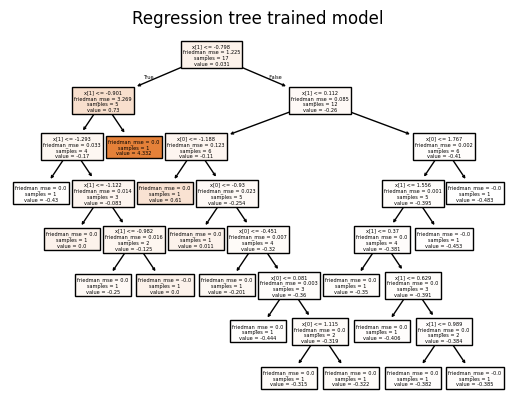

In [33]:
# VISUALIZACIÓN DE ÁRBOL DE REGRESIÓN

from sklearn.tree import plot_tree
plt.figure()
plot_tree(clf, filled=True)
plt.title("Regression tree trained model")
plt.show()

In [21]:
# ARBOL DE PREDICION PODADO (PRUNING)
#####################################
# Efecturar una poda del arbol con un nivel de profundidad de 5
params={'ccp_alpha':0.0, 'criterion':'mse','max_depth':5, # max_depth: muestra los niveles del arbol
        'max_features':'sqrt', 'max_leaf_nodes':None,  #valor_max. representado como: 'auto','sqrt','log2', definir cantidad max. de nodos
        'min_impurity_decrease':0.0,
        'min_samples_leaf':1, 'min_samples_split':2,   # nro. nodos hojas:1 , nro. de divisiones:2
        'random_state':None, 'splitter':'best'}  # division: la mejor/aleatoria

# Using max_features: 'squrt' o 'log2' we can reduce the MSE score.

model2=DecisionTreeRegressor(**params)
clf2=model2.fit(x_train, y_train)
predictionsReg2=model2.predict(x_test) # prediccion del conjunto de testing de las var. observables o factores
predictionsReg2=np.array(predictionsReg2,dtype='float64')
predictionsReg2.dtype

C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\tree\_classes.py:397: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warnings.warn(


dtype('float64')

In [22]:
y_test=np.array(y_test,dtype='float64')

In [23]:
# Se crea un dataframe para comparar las predicciones con el valor real
df_predicciones2=pd.DataFrame(y_test,predictionsReg2)
df_predicciones2

,0
1.607794,-1.041157
1.607794,-0.236915
0.257141,0.764107
-0.808194,-0.127007
-1.767533,-0.514772


In [24]:
# 5. Evaluate predictions
mae=mean_absolute_error(y_test,predictionsReg2)  # var. rpta. del conjunto de testing y de la prediccion 
mse=mean_squared_error(y_test, predictionsReg2)
R2=r2_score(y_test, predictionsReg2)
rmse=mse**(1/2.0)
print("The mean absolte error (MAE) on test set: {:.5f}".format(mae))  # error abs. promedio
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))  # error cuadratico medio
print("The root mean squared error (RMSE) on test set: {:.4f}".format(rmse)) # raiz cuadrada del error cuadratico medio
print("The variance is (R_2) on test set: {:.4f}".format(R2)) # raiz cuadrada del error cuadratico medio

The mean absolte error (MAE) on test set: 1.38692
The mean squared error (MSE) on test set: 2.5421
The root mean squared error (RMSE) on test set: 1.5944
The variance is (R_2) on test set: -6.3133


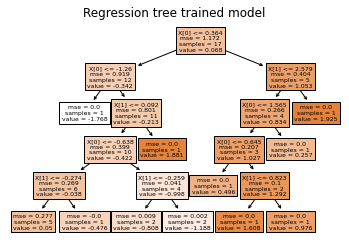

In [25]:
# 6. VISUALIZACION DEL ARBOL DE DECISION
from sklearn.tree import plot_tree
plt.figure()
plot_tree(clf2, filled=True)
plt.title("Regression tree trained model")
plt.show()
